# Understand the basic Image Classification pipeline and the data-driven approach (train/predict stages) 

In [0]:
# Include all the packages need to resolve the problem
from __future__ import absolute_import, division, print_function
import numpy as np
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, ReLU, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


# 1. Data fetching and understand the train/val/test splits.

In [0]:
import h5py
# Open the file as readonly
 h5f = h5py.File('./SVHN_single_grey1.h5', 'r')

# h5f = h5py.File('/content/drive/My Drive/AIML/Neural Network/Project2/data/SVHN_single_grey1.h5', 'r')

# Load the training, test and validation set
x_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
x_test = h5f['X_test'][:]
y_test = h5f['y_test'][:]
x_val = h5f['X_val'][:]
y_val = h5f['y_val'][:]

# Close this file
h5f.close()

In [61]:
print("No of Train samples:", x_train.shape[0])
print("No of Test samples:", x_test.shape[0])
print("No of Val samples:", x_val.shape[0])

No of Train samples: 42000
No of Test samples: 18000
No of Val samples: 60000


In [0]:
print("Train image size:", x_train.shape[1:])

Train image size: (32, 32)


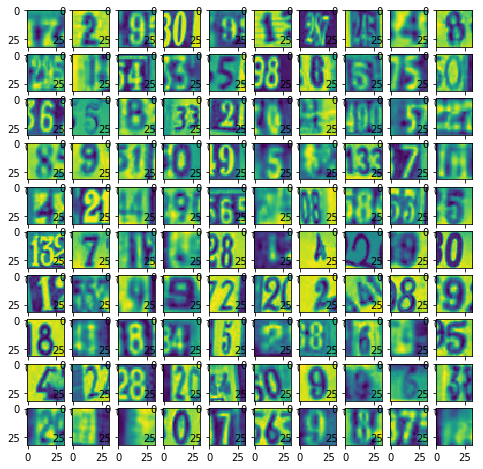

In [0]:
# View 100 sample images from the test dataset
%matplotlib inline

import matplotlib.pyplot as plt
w=10
h=10
fig=plt.figure(figsize=(8, 8))
columns = 10
rows = 10
for i in range(1, columns*rows +1):
    img = x_test[i]
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
plt.show()

# 2. Implement and apply an optimal k-Nearest Neighbor (kNN) classifier (7.5 Points)

In [0]:
from sklearn.neighbors import KNeighborsClassifier 

In [0]:
# Create a k-NN classifier with 7 neighbors: knn
knn = KNeighborsClassifier(n_neighbors=7)

In [65]:
# Fit the classifier to the training data
knn.fit(x_train.reshape(x_train.shape[0], -1), y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=7, p=2,
                     weights='uniform')

In [66]:
# Print the accuracy, enable later
knn_score = knn.score(x_test.reshape(x_test.shape[0], -1), y_test)
print("KNN Score =", knn_score)

KNN Score = 0.36444444444444446


In [0]:
neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

In [0]:
# Loop over different values of k
for i, k in enumerate(neighbors):
    # Setup a k-NN Classifier with k neighbors: knn
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier to the training data
    knn.fit(x_train.reshape(x_train.shape[0], -1), y_train)
    
    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(x_train.reshape(x_train.shape[0], -1), y_train)

    #Compute accuracy on the testing set
    test_accuracy[i] = knn.score(x_test.reshape(x_test.shape[0], -1), y_test)
    
    print("Neighbors = ", k, "Train Accuracy= ", train_accuracy[i], " Test Accuracy =  ", test_accuracy[i])

Neighbors =  1 Train Accuracy=  1.0  Test Accuracy =   0.3438888888888889
Neighbors =  2 Train Accuracy=  0.6419047619047619  Test Accuracy =   0.31833333333333336
Neighbors =  3 Train Accuracy=  0.5957142857142858  Test Accuracy =   0.33
Neighbors =  4 Train Accuracy=  0.5902380952380952  Test Accuracy =   0.34444444444444444
Neighbors =  5 Train Accuracy=  0.5769047619047619  Test Accuracy =   0.35555555555555557
Neighbors =  6 Train Accuracy=  0.5573809523809524  Test Accuracy =   0.35944444444444446
Neighbors =  7 Train Accuracy=  0.5380952380952381  Test Accuracy =   0.36444444444444446
Neighbors =  8 Train Accuracy=  0.535952380952381  Test Accuracy =   0.3688888888888889


# 3. Print the classification metric report (2.5 Points)

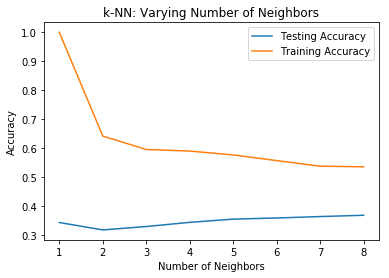

In [0]:
# Generate plot
plt.title('k-NN: Varying Number of Neighbors')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()

In [0]:
knn_neighbors = np.argmax(test_accuracy)+1
knn_accuracy = max(test_accuracy)
print("Best KNN Score when neighbors=", knn_neighbors)
print("Accuracy score = ", knn_accuracy)

Best KNN Score when neighbors= 8
Accuracy score =  0.3688888888888889


# 4. Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

### Reshape train and test sets into shapes compatible with keras models
### (Keras expects data to be in the format (N_E.N_H,N_W,N_C) N_E = Number of Examples, N_H = height, N_W = Width, N_C = Number of Channels.)

In [0]:
# input image dimensions
img_rows, img_cols = 32, 32

#Keras expects data to be in the format (N_E.N_H,N_W,N_C)  N_E = Number of Examples, N_H = height, N_W = Width, N_C = Number of Channels.
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
x_val = x_val.reshape(x_val.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

### Pre-processing the dataset

In [79]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_val = x_val.astype('float32')

#Normalizing the input
x_train /= 255
x_test /= 255
x_val /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_val.shape[0], 'val samples')

x_train shape: (42000, 32, 32, 1)
42000 train samples
18000 test samples
60000 val samples


### Convert Labels from digits to one hot vectors

In [80]:
np.unique(y_train), np.unique(y_test), np.unique(y_val)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

In [0]:
num_classes = len(np.unique(y_train))

In [0]:
import keras
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [0]:
print(y_train[0])

2


### Building the CNN sequential model

In [0]:
batch_size = 128
num_classes = 10

In [0]:
#Initialize the model
model = Sequential()

#Add a Convolutional Layer with 32 filters of size 3X3 and activation function as 'ReLU' 
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape,name='conv_1'))

#Add a Convolutional Layer with 64 filters of size 3X3 and activation function as 'ReLU' 
model.add(Conv2D(64, (3, 3), activation='relu',name='conv_2'))

#Add a MaxPooling Layer of size 2X2 
model.add(MaxPooling2D(pool_size=(2, 2),name='max_1'))

#Apply Dropout with 0.25 probability 
model.add(Dropout(0.25,name='drop_1'))

#Flatten the layer
model.add(Flatten())

#Add Fully Connected Layer with 128 units and activation function as 'ReLU'
model.add(Dense(128, activation='relu',name='dense_1'))

#Apply Dropout with 0.5 probability 
model.add(Dropout(0.5,name='drop_2'))

#Add Fully Connected Layer with 10 units and activation function as 'softmax'
model.add(Dense(num_classes, activation='softmax',name='dense_2'))

# 5. Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points)

In [0]:
from keras.optimizers import SGD
from keras.losses import categorical_crossentropy

#To use adam optimizer for learning weights with learning rate = 0.001
optimizer = SGD(lr=0.001, decay=1e-6, momentum=0.9)
#Set the loss function and optimizer for the model training
model.compile(loss=categorical_crossentropy,
              optimizer=optimizer,
              metrics=['accuracy'])

In [12]:
#Training on the dataset
model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=12,
          #verbose=1,
          validation_data=(x_val, y_val))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 42000 samples, validate on 60000 samples
Epoch 1/20
42000/42000 [==============================] - 190s 5ms/step - loss: 2.3036 - acc: 0.1026 - val_loss: 2.3008 - val_acc: 0.1062
Epoch 2/20
42000/42000 [==============================] - 190s 5ms/step - loss: 2.3006 - acc: 0.1149 - val_loss: 2.2986 - val_acc: 0.1599
Epoch 3/20
42000/42000 [==============================] - 189s 5ms/step - loss: 2.2987 - acc: 0.1276 - val_loss: 2.2956 - val_acc: 0.1874
Epoch 4/20
42000/42000 [==============================] - 189s 5ms/step - loss: 2.2958 - acc: 0.1383 - val_loss: 2.2906 - val_acc: 0.2257
Epoch 5/20
42000/42000 [==============================] - 191s 5ms/step - loss: 2.2900 - acc: 0.1515 - val_loss: 2.2803 - val_acc: 0.2425
Epoch 6/20
42000/42000 [==============================] - 192s 5ms/step - loss: 2.2777 - acc: 0.1730 - val_loss: 2.2533 - val_acc: 0.3198
Epoch 7/20
42000/42000 [====

KeyboardInterrupt: ignored

In [13]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv_1 (Conv2D)              (None, 30, 30, 32)        320       
_________________________________________________________________
conv_2 (Conv2D)              (None, 28, 28, 64)        18496     
_________________________________________________________________
max_1 (MaxPooling2D)         (None, 14, 14, 64)        0         
_________________________________________________________________
drop_1 (Dropout)             (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 12544)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               1605760   
_________________________________________________________________
drop_2 (Dropout)             (None, 128)              

## Evaluate trained model on the test set

In [14]:
#Testing the model on test set
score = model.evaluate(x_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

18000/18000 [==============================] - 17s 932us/step
Test loss: 1.2204194292492336
Test accuracy: 0.6577777777777778


# 6. Implement batch normalization for training the neural network (2.5points)

In [0]:
#Initialize the model
model_1 = Sequential()

#Add a Convolutional Layer with 32 filters of size 3X3
model_1.add(Conv2D(32, kernel_size=(3, 3),
                 input_shape=input_shape,name='conv_1'))
# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_1', epsilon=0.001, momentum=0.99))
# Apply ReLU activation
model_1.add(ReLU(name='relu_1'))

#Add a Convolutional Layer with 64 filters of size 3X3 
model_1.add(Conv2D(64, (3, 3), name='conv_2'))
# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_2', epsilon=0.001, momentum=0.99))
# Apply ReLU activation
model_1.add(ReLU(name='relu_2'))

#Add a MaxPooling Layer of size 2X2 
model_1.add(MaxPooling2D(pool_size=(2, 2),name='max_1'))

# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_3', epsilon=0.001, momentum=0.99))

#Flatten the layer
model_1.add(Flatten())

#Add Fully Connected Layer with 128 units and activation function as 'ReLU'
model_1.add(Dense(128, activation='relu',name='dense_1'))

# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_4', epsilon=0.001, momentum=0.99))

#Add Fully Connected Layer with 10 units and activation function as 'softmax'
model_1.add(Dense(num_classes, activation='softmax',name='dense_2'))

In [0]:
from keras.optimizers import SGD
from keras.losses import categorical_crossentropy

#To use adam optimizer for learning weights with learning rate = 0.001
optimizer = SGD(lr=0.01, decay=1e-6, momentum=0.9)
#Set the loss function and optimizer for the model training
model_1.compile(loss=categorical_crossentropy,
              optimizer=optimizer,
              metrics=['accuracy'])

In [89]:
#Training on the dataset
model_1.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=12,
          verbose=1,
          validation_data=(x_val, y_val))

Train on 42000 samples, validate on 60000 samples
Epoch 1/12
42000/42000 [==============================] - 394s 9ms/step - loss: 0.8196 - acc: 0.7443 - val_loss: 0.6161 - val_acc: 0.8053
Epoch 2/12
42000/42000 [==============================] - 389s 9ms/step - loss: 0.3908 - acc: 0.8833 - val_loss: 0.4440 - val_acc: 0.8658
Epoch 3/12
42000/42000 [==============================] - 388s 9ms/step - loss: 0.2921 - acc: 0.9141 - val_loss: 0.3243 - val_acc: 0.9052
Epoch 4/12
42000/42000 [==============================] - 393s 9ms/step - loss: 0.2266 - acc: 0.9345 - val_loss: 0.2934 - val_acc: 0.9143
Epoch 5/12
42000/42000 [==============================] - 392s 9ms/step - loss: 0.1732 - acc: 0.9501 - val_loss: 0.2017 - val_acc: 0.9456
Epoch 6/12
  512/42000 [..............................] - ETA: 4:34 - loss: 0.1401 - acc: 0.9688

KeyboardInterrupt: ignored

In [90]:
model_1.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv_1 (Conv2D)              (None, 30, 30, 32)        320       
_________________________________________________________________
batchnorm_1 (BatchNormalizat (None, 30, 30, 32)        128       
_________________________________________________________________
relu_1 (ReLU)                (None, 30, 30, 32)        0         
_________________________________________________________________
conv_2 (Conv2D)              (None, 28, 28, 64)        18496     
_________________________________________________________________
batchnorm_2 (BatchNormalizat (None, 28, 28, 64)        256       
_________________________________________________________________
relu_2 (ReLU)                (None, 28, 28, 64)        0         
_________________________________________________________________
max_1 (MaxPooling2D)         (None, 14, 14, 64)       

In [91]:
#Testing the model on test set
score = model_1.evaluate(x_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

18000/18000 [==============================] - 35s 2ms/step
Test loss: 0.4641064270801014
Test accuracy: 0.8672222222222222


# 7. Understand the differences and trade-offs between traditional and NN classifiers with the help of classification metrics (5 Points)

In [0]:
import pandas as pd
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix,recall_score, precision_score, f1_score, auc, roc_curve

In [75]:
print("Confusion Matrix for KNN classifier")
print("")

y_predict = knn.predict(x_test.reshape(x_test.shape[0], -1))
metrics.confusion_matrix(y_predict, y_test)

Confusion Matrix for KNN classifier



array([[112,  12,  25,  21,  21,  30,  54,  14,  43,  46],
       [ 13, 102,  30,  36,  27,  23,  22,  36,  12,  18],
       [  8,   6,  57,  15,  12,  15,  12,  21,  10,  14],
       [  9,  11,  15,  51,  12,  24,  10,   9,  14,   9],
       [ 12,   8,   9,   6,  80,   2,  17,   4,  12,   4],
       [  7,   3,   2,  11,   5,  45,  10,   7,  14,   7],
       [  9,   5,   4,   9,   6,  19,  43,   6,  19,  11],
       [  3,   9,  12,   6,   5,   8,   4,  83,   3,  10],
       [ 13,   2,   8,  11,   2,  12,   9,   2,  33,  16],
       [ 14,   0,   6,   2,   6,  13,   8,   3,  20,  50]])

In [76]:
print("Classification Report for KNN classifier")
print("")

pd.DataFrame(data=[accuracy_score(y_test, y_predict,'weighted'), 
                   recall_score(y_test, y_predict,average ='weighted'),
                   precision_score(y_test, y_predict,average ='weighted'),
                   f1_score(y_test, y_predict,average ='weighted')], 
             index=["accuracy", "recall", "precision", "f1Score"])


Classification Report for KNN classifier



,0
accuracy,0.364444
recall,0.364444
precision,0.381916
f1Score,0.356414


In [93]:
print("Confusion Matrix for CNN classifier")
print("")

y_predict = model_1.predict(x_test)
metrics.confusion_matrix(y_test.argmax(axis=1), y_predict.argmax(axis=1))

Confusion Matrix for CNN classifier



array([[1677,   26,    8,    5,    7,    3,   13,   47,   11,   17],
       [  38, 1608,   18,   11,   39,    8,    5,   80,   12,    9],
       [  21,   30, 1551,   12,   16,    9,    3,  107,   12,   42],
       [  12,   46,   20, 1347,   22,  105,   18,   72,   43,   34],
       [  21,   67,   31,   10, 1597,   10,   18,   36,    6,   16],
       [   8,   13,   12,   38,   10, 1580,   34,   21,   25,   27],
       [  59,   25,    8,   14,   16,   58, 1524,   30,   84,   14],
       [  17,   45,   28,   11,   13,   11,    5, 1667,    3,    8],
       [  55,   46,   14,   20,    9,   22,   44,   42, 1512,   48],
       [  82,   28,   19,   14,   15,   23,   10,   36,   30, 1547]])

In [94]:
print("Classification Report for CNN classifier")
print("")

pd.DataFrame(data=[accuracy_score(y_test.argmax(axis=1), y_predict.argmax(axis=1),'weighted'), 
                   recall_score(y_test.argmax(axis=1), y_predict.argmax(axis=1),average ='weighted'),
                   precision_score(y_test.argmax(axis=1), y_predict.argmax(axis=1),average ='weighted'),
                   f1_score(y_test.argmax(axis=1), y_predict.argmax(axis=1),average ='weighted')], 
             index=["accuracy", "recall", "precision", "f1Score"])

Classification Report for CNN classifier



,0
accuracy,0.867222
recall,0.867222
precision,0.870647
f1Score,0.867283
